# 01 — Minimal RW Population: Baseline

Before stress-testing expectile vs. quantile learning under noise (notebook
02) and in active decision tasks (notebook 03), this checks that a minimal
population of Rescorla-Wagner units with heterogeneous asymmetric learning
rates reproduces the three qualitative signatures the rest of the project
builds on:

1. an abstraction hierarchy (mean > variance > kurtosis) in the same
   ballpark as the real striatal recordings,
2. opponent geometry between optimistic (tau > 0.5, "D1-like") and
   pessimistic (tau <= 0.5, "D2-like") units, with no D1/D2 architecture
   imposed — just heterogeneity in tau,
3. a linear behavioral readout that discriminates rewarded from unrewarded
   cues but is blind to Fixed vs. Variable, matching the real animals'
   behavior.

This is a sanity gate, not a paper result: if the toy model didn't show
these three things under clean conditions, there would be no point asking
how it behaves under noise.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp, ttest_ind, sem

import rw_utils as rwu

ARTIFACT_DIR = "artifacts"
const = np.load(os.path.join(ARTIFACT_DIR, "empirical_constants.npz"))
EMP_AI = dict(zip(const["stat_names"], const["ai_mean"]))
EMP_COS = dict(zip(const["stat_names"], const["cos_align_mean"]))
L_POOLED = const["L_pooled"]
N_UNITS_RW = int(const["n_units_rw"])
OBS_NOISE_SD = float(const["obs_noise_sd"])
N_TRIALS_PER_ODOR = int(const["median_trials_per_condition"])
N_PROBE = max(5, N_TRIALS_PER_ODOR // 2)

print(f"Loaded empirical constants: AI={dict((k, round(float(v), 3)) for k, v in EMP_AI.items())}")
print(f"RW population size (matches noise calibration): {N_UNITS_RW}")
print(f"Trial regime from real data: {N_TRIALS_PER_ODOR} trials/odor, probing last {N_PROBE}")

Loaded empirical constants: AI={np.str_('mean'): 0.623, np.str_('variance'): 0.098, np.str_('kurtosis'): 0.006}
RW population size (matches noise calibration): 50
Trial regime from real data: 35 trials/odor, probing last 17


## Abstraction hierarchy under clean, realistic-noise conditions

In [2]:
N_SEEDS = 30

def population_hierarchy(rule="expectile", n_seeds=N_SEEDS):
    rows = []
    for seed in range(n_seeds):
        alpha_plus, alpha_minus, taus = rwu.sample_alphas(N_UNITS_RW, seed=seed)
        probe_main = rwu.train_rw_probed(
            "SameRewDist", alpha_plus, alpha_minus, rule=rule,
            n_trials_per_odor=N_TRIALS_PER_ODOR, n_probe=N_PROBE,
            L_obs=L_POOLED, seed=seed)
        probe_srv = rwu.train_rw_probed(
            "SameRewVar", alpha_plus, alpha_minus, rule=rule,
            n_trials_per_odor=N_TRIALS_PER_ODOR, n_probe=N_PROBE,
            L_obs=L_POOLED, seed=seed + 100_000)
        for stat, c in rwu.CONTRASTS_RW.items():
            probe = probe_main if c["task"] == "SameRewDist" else probe_srv
            cr = rwu.build_cr_from_probes(probe)
            res = rwu.cross_identity_decode(cr, np.arange(cr.shape[1]), c["neg"], c["pos"], 0, seed=seed)
            if res is None:
                continue
            cross, within, _ = res
            _, cos = rwu.sdt_cross_session(cr, np.arange(cr.shape[1]), c["neg"], c["pos"], 0)
            rows.append(dict(rule=rule, stat=stat, seed=seed, cross=cross,
                              ai=rwu.abstraction_index(cross, within), cos_align=cos))
    return pd.DataFrame(rows)

df_baseline = population_hierarchy("expectile")
order = ["mean", "variance", "kurtosis"]
summ = df_baseline.groupby("stat").agg(ai_mean=("ai", "mean"), ai_sem=("ai", "sem"),
                                        cos_mean=("cos_align", "mean")).reindex(order)
print(summ.to_string(float_format=lambda v: f"{v:.3f}"))
print("\nEmpirical reference AI:", {k: round(float(v), 3) for k, v in EMP_AI.items()})

          ai_mean  ai_sem  cos_mean
stat                               
mean        0.501   0.023     0.714
variance    0.030   0.030     0.024
kurtosis   -0.009   0.027     0.016

Empirical reference AI: {np.str_('mean'): 0.623, np.str_('variance'): 0.098, np.str_('kurtosis'): 0.006}


## Opponent geometry from tau-heterogeneity alone

In [3]:
def opponent_geometry(n_seeds=N_SEEDS):
    rows = []
    for seed in range(n_seeds):
        alpha_plus, alpha_minus, taus = rwu.sample_alphas(N_UNITS_RW, seed=seed)
        V = rwu.train_rw_population("SameRewDist", alpha_plus, alpha_minus, seed=seed)
        d1, d2 = np.where(taus > 0.5)[0], np.where(taus <= 0.5)[0]
        if len(d1) < 2 or len(d2) < 2:
            continue
        rows.append(dict(seed=seed,
                          d1_delta=rwu.nothing_relative_distance_V(V, d1),
                          d2_delta=rwu.nothing_relative_distance_V(V, d2)))
    return pd.DataFrame(rows)

df_opp = opponent_geometry()
_, p_d1 = ttest_1samp(df_opp["d1_delta"], 0)
_, p_d2 = ttest_1samp(df_opp["d2_delta"], 0)
print(f"D1-like (tau>0.5)  d(N,Var)-d(N,Fix) = {df_opp['d1_delta'].mean():+.3f}  p={p_d1:.2e}")
print(f"D2-like (tau<=0.5) d(N,Var)-d(N,Fix) = {df_opp['d2_delta'].mean():+.3f}  p={p_d2:.2e}")

D1-like (tau>0.5)  d(N,Var)-d(N,Fix) = +2.111  p=1.35e-18
D2-like (tau<=0.5) d(N,Var)-d(N,Fix) = -2.525  p=1.59e-17


## Behavioral readout: blind to Fixed vs. Variable

In [4]:
def readout_summary(n_seeds=N_SEEDS):
    rows = []
    for seed in range(n_seeds):
        alpha_plus, alpha_minus, _ = rwu.sample_alphas(N_UNITS_RW, seed=seed)
        V = rwu.train_rw_population("SameRewDist", alpha_plus, alpha_minus, seed=seed)
        w, Vz = rwu.train_linear_readout(V, "SameRewDist", seed=seed)
        readout = Vz @ w
        rows.append(dict(nothing=readout[[0, 1]].mean(), fixed=readout[[2, 3]].mean(),
                          variable=readout[[4, 5]].mean()))
    return pd.DataFrame(rows)

df_readout = readout_summary()
_, p_nf = ttest_1samp(df_readout["nothing"] - df_readout["fixed"], 0)
_, p_fv = ttest_1samp(df_readout["fixed"] - df_readout["variable"], 0)
for col in ["nothing", "fixed", "variable"]:
    print(f"  {col:10s}: {df_readout[col].mean():+.3f} +/- {df_readout[col].sem():.3f}")
print(f"Nothing vs Fixed:   diff={(df_readout['nothing']-df_readout['fixed']).mean():+.3f}  p={p_nf:.2e}")
print(f"Fixed vs Variable:  diff={(df_readout['fixed']-df_readout['variable']).mean():+.3f}  p={p_fv:.2e}")

  nothing   : -2.605 +/- 0.454
  fixed     : +1.198 +/- 0.267
  variable  : +1.407 +/- 0.224
Nothing vs Fixed:   diff=-3.803  p=9.34e-06
Fixed vs Variable:  diff=-0.209  p=2.81e-01


## Figure: the three baseline signatures together

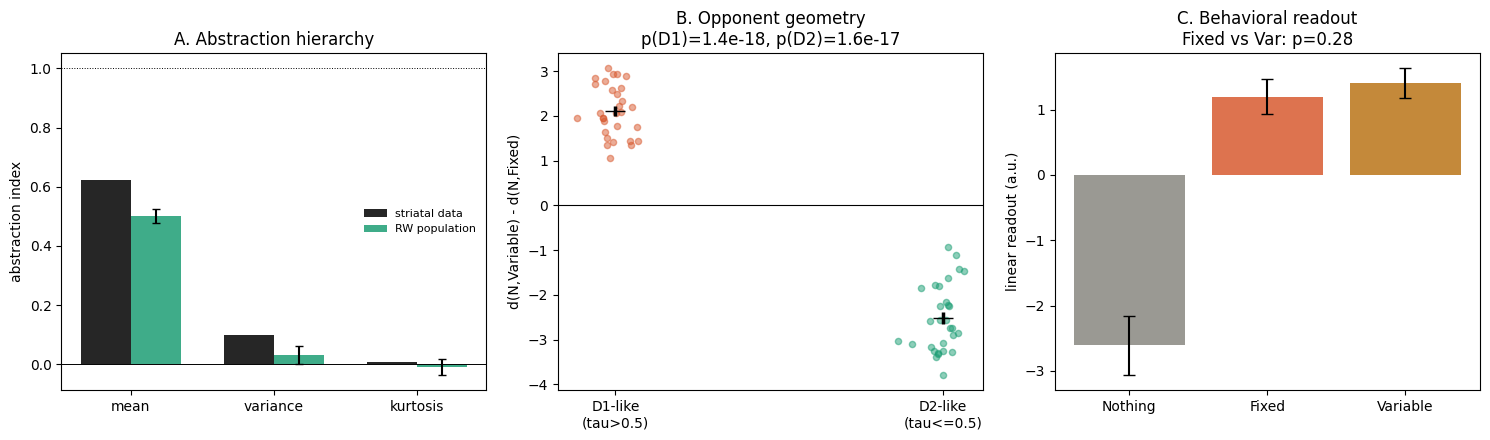

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
x = np.arange(3); w = 0.35
emp_ai = [EMP_AI[s] for s in order]
rw_ai = [summ.loc[s, "ai_mean"] for s in order]
rw_ai_sem = [summ.loc[s, "ai_sem"] for s in order]
ax.bar(x - w/2, emp_ai, w, color="k", alpha=0.85, label="striatal data")
ax.bar(x + w/2, rw_ai, w, yerr=rw_ai_sem, capsize=3, color=rwu.TEAL, alpha=0.85, label="RW population")
ax.axhline(0, color="k", lw=0.7); ax.axhline(1, color="k", ls=":", lw=0.7)
ax.set_xticks(x); ax.set_xticklabels(order); ax.set_ylabel("abstraction index")
ax.set_title("A. Abstraction hierarchy")
ax.legend(fontsize=8, frameon=False)

ax = axes[1]
for i, (col, color, lab) in enumerate([("d1_delta", rwu.CORAL, "D1-like"), ("d2_delta", rwu.TEAL, "D2-like")]):
    vals = df_opp[col]
    jit = np.random.default_rng(i).normal(0, 0.05, len(vals))
    ax.scatter(np.full(len(vals), i) + jit, vals, s=20, alpha=0.5, color=color)
    ax.errorbar(i, vals.mean(), yerr=vals.sem(), fmt="_", ms=14, lw=2.5, color="k")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks([0, 1]); ax.set_xticklabels(["D1-like\n(tau>0.5)", "D2-like\n(tau<=0.5)"])
ax.set_ylabel("d(N,Variable) - d(N,Fixed)")
ax.set_title(f"B. Opponent geometry\np(D1)={p_d1:.1e}, p(D2)={p_d2:.1e}")

ax = axes[2]
conds = ["nothing", "fixed", "variable"]
ax.bar(range(3), [df_readout[c].mean() for c in conds],
       yerr=[df_readout[c].sem() for c in conds], capsize=4,
       color=[rwu.GRAY, rwu.CORAL, rwu.AMBER], alpha=0.85)
ax.set_xticks(range(3)); ax.set_xticklabels(["Nothing", "Fixed", "Variable"])
ax.set_ylabel("linear readout (a.u.)")
ax.set_title(f"C. Behavioral readout\nFixed vs Var: p={p_fv:.2f}")

plt.tight_layout()
os.makedirs(os.path.join(ARTIFACT_DIR, "..", "figures"), exist_ok=True)
plt.savefig(os.path.join(ARTIFACT_DIR, "..", "figures", "01_rw_baseline.pdf"), bbox_inches="tight")
plt.show()

df_baseline.to_csv(os.path.join(ARTIFACT_DIR, "baseline_hierarchy.csv"), index=False)
df_opp.to_csv(os.path.join(ARTIFACT_DIR, "baseline_opponency.csv"), index=False)
df_readout.to_csv(os.path.join(ARTIFACT_DIR, "baseline_readout.csv"), index=False)

## Which tau-distribution shape best matches the data?

The population above assumes tau ~ Uniform(0.05, 0.95). This checks whether
that assumption matters, by comparing it against a bimodal (D1/D2-separated),
unimodal (mostly-mean), and D2-heavy tau distribution.

In [6]:
def sample_alphas_shaped(n_units, shape, base_rate=0.05, seed=0):
    rng = np.random.default_rng(seed)
    if shape == "uniform":
        taus = rng.uniform(0.05, 0.95, n_units)
    elif shape == "bimodal":
        half = n_units // 2
        taus = np.concatenate([rng.uniform(0.05, 0.35, half), rng.uniform(0.65, 0.95, n_units - half)])
        rng.shuffle(taus)
    elif shape == "unimodal":
        taus = np.clip(rng.normal(0.5, 0.12, n_units), 0.05, 0.95)
    elif shape == "d2_heavy":
        taus = np.clip(rng.beta(2, 2.5, n_units), 0.02, 0.98)
    else:
        raise ValueError(shape)
    return base_rate * 2 * taus, base_rate * 2 * (1 - taus), taus

N_SEEDS_SHAPE = 100
shape_rows = []
for shape in ["uniform", "bimodal", "unimodal", "d2_heavy"]:
    for seed in range(N_SEEDS_SHAPE):
        a_p, a_m, taus = sample_alphas_shaped(N_UNITS_RW, shape=shape, seed=seed)
        probe_main = rwu.train_rw_probed("SameRewDist", a_p, a_m, n_trials_per_odor=N_TRIALS_PER_ODOR,
                                          n_probe=N_PROBE, L_obs=L_POOLED, seed=seed)
        probe_srv = rwu.train_rw_probed("SameRewVar", a_p, a_m, n_trials_per_odor=N_TRIALS_PER_ODOR,
                                         n_probe=N_PROBE, L_obs=L_POOLED, seed=seed + 100_000)
        for stat, c in rwu.CONTRASTS_RW.items():
            probe = probe_main if c["task"] == "SameRewDist" else probe_srv
            cr = rwu.build_cr_from_probes(probe)
            res = rwu.cross_identity_decode(cr, np.arange(cr.shape[1]), c["neg"], c["pos"], 0, seed=seed)
            if res is None:
                continue
            cross, within, _ = res
            shape_rows.append(dict(shape=shape, seed=seed, stat=stat,
                                    ai=rwu.abstraction_index(cross, within)))

df_shape = pd.DataFrame(shape_rows)
summ_shape = df_shape.groupby(["shape", "stat"])["ai"].mean().unstack().reindex(
    ["uniform", "bimodal", "unimodal", "d2_heavy"])
sse = {s: sum((summ_shape.loc[s, k] - EMP_AI[k]) ** 2 for k in EMP_AI) for s in summ_shape.index}

print(summ_shape.to_string(float_format=lambda v: f"{v:.3f}"))
print("\nSum squared error vs. empirical AI (lower = better fit):")
for s, v in sorted(sse.items(), key=lambda x: x[1]):
    print(f"  {s:10s}: SSE={v:.4f}")

df_shape.to_csv(os.path.join(ARTIFACT_DIR, "baseline_tau_shape.csv"), index=False)

stat      kurtosis  mean  variance
shape                             
uniform     -0.028 0.543     0.072
bimodal     -0.022 0.527     0.107
unimodal    -0.030 0.577     0.002
d2_heavy    -0.031 0.559     0.037

Sum squared error vs. empirical AI (lower = better fit):
  uniform   : SSE=0.0082
  d2_heavy  : SSE=0.0092
  bimodal   : SSE=0.0101
  unimodal  : SSE=0.0126
